Total number of entries: 2832


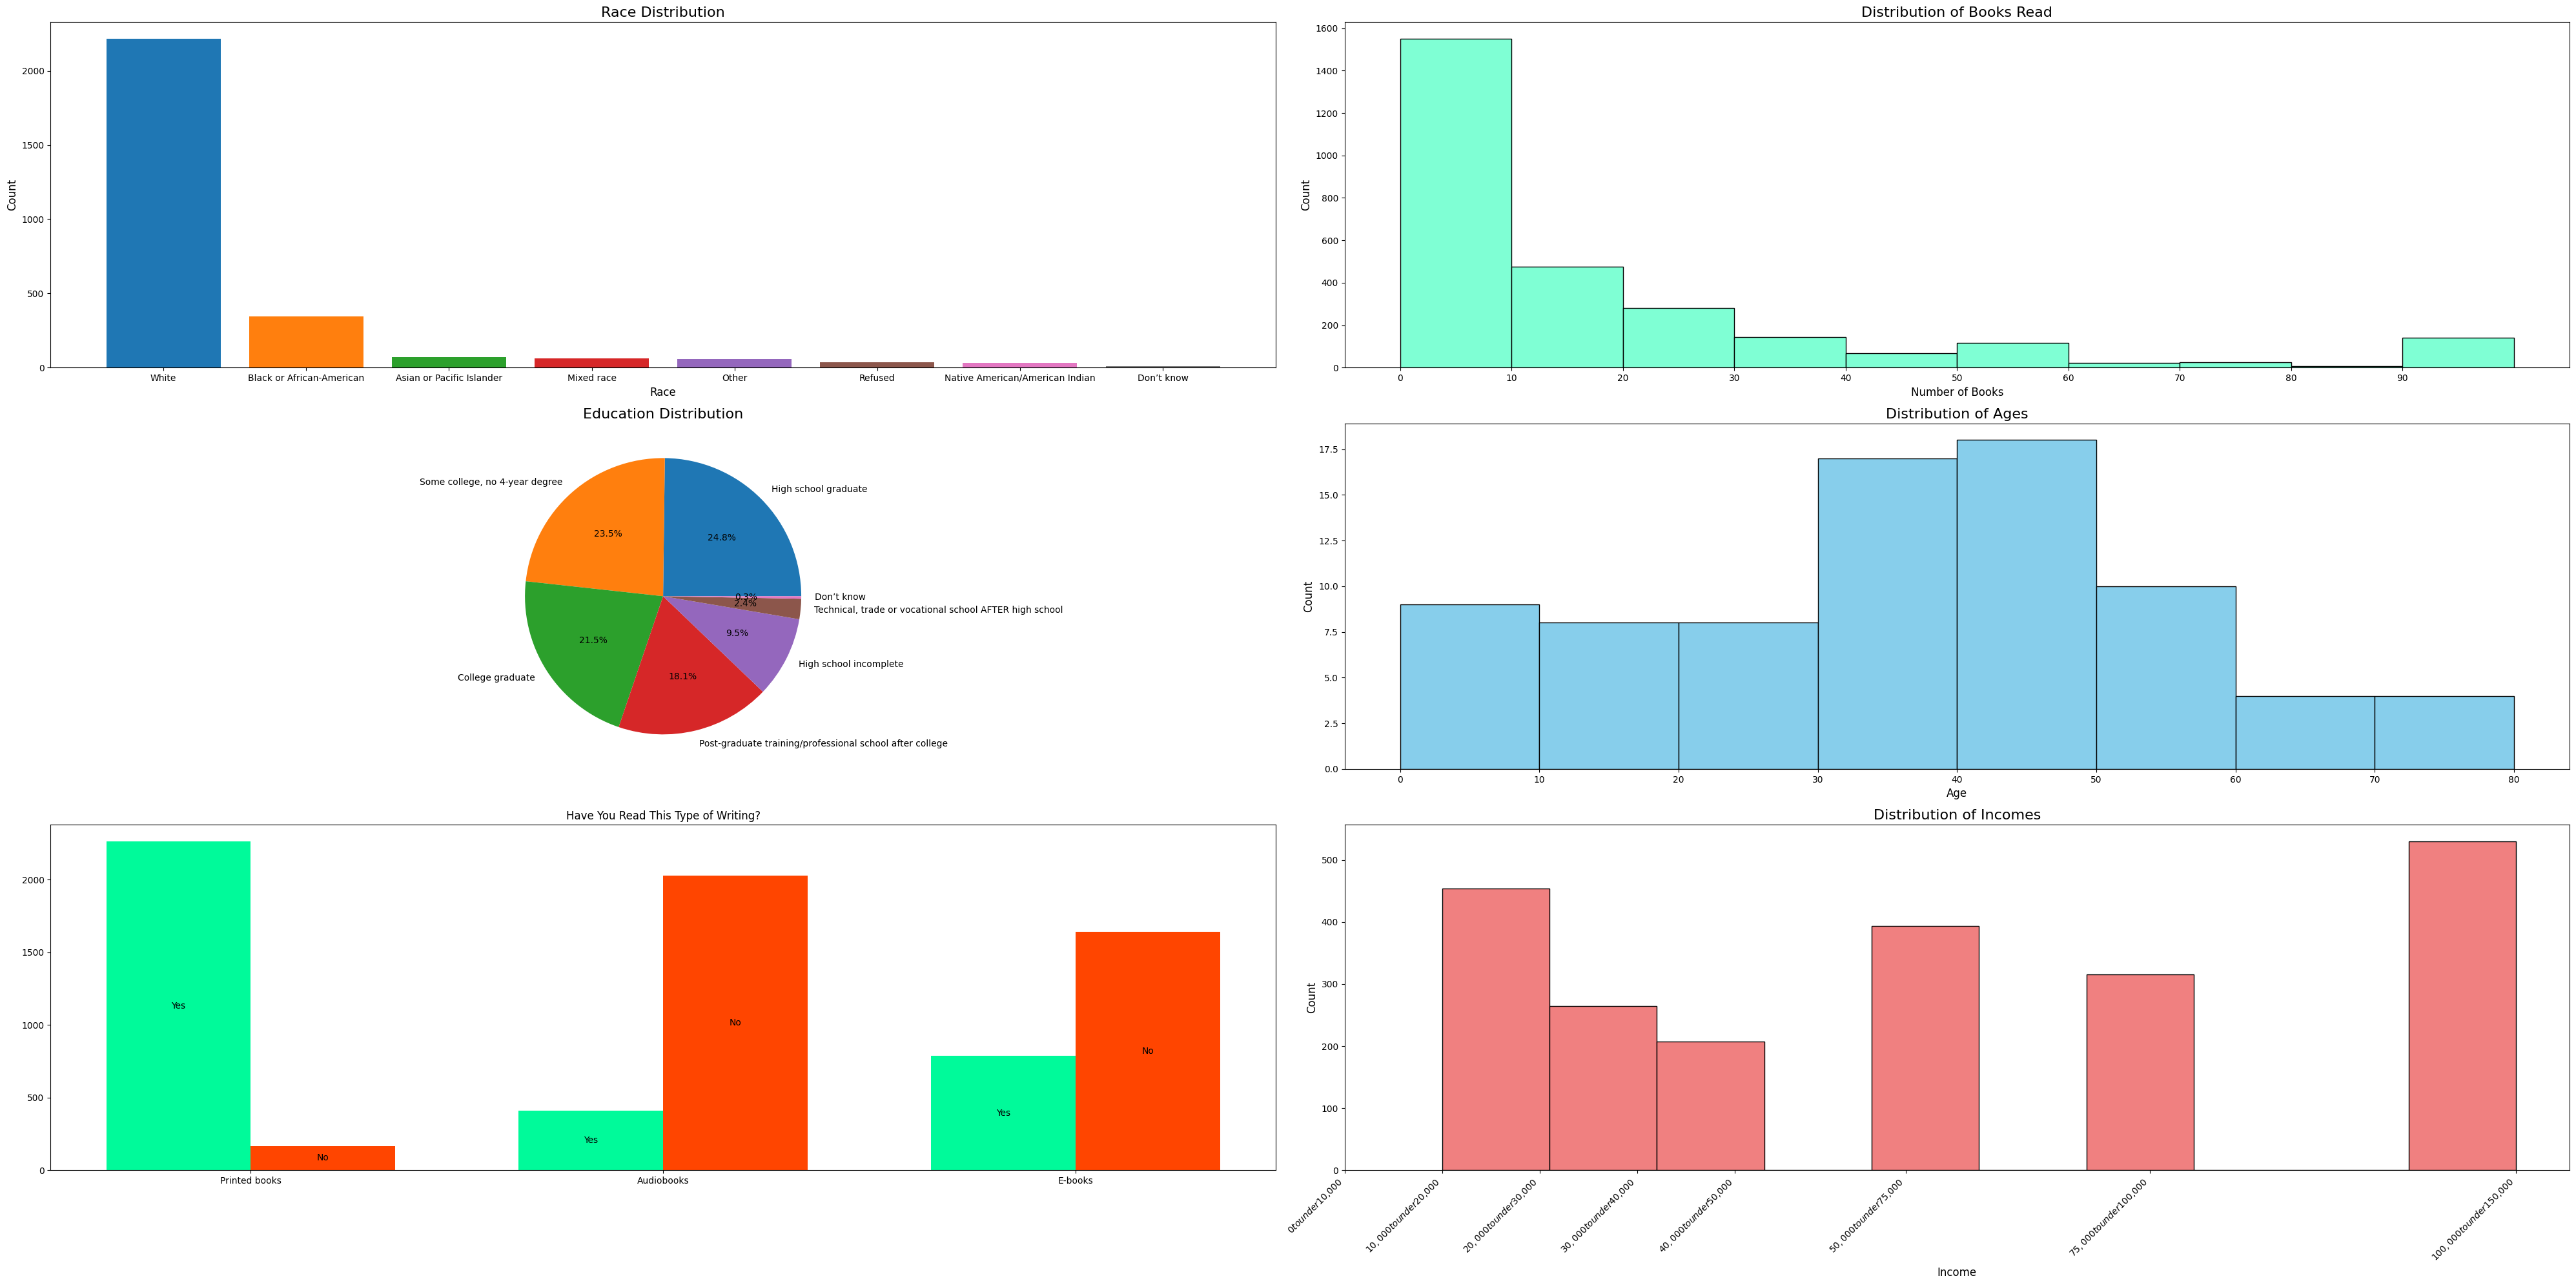

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Read file
df = pd.read_csv('reading_habits.csv')

# Exploratory Analysis
total_entries = len(df)
print(f'Total number of entries: {total_entries}')

# Lists
race_counts = df['Race'].value_counts()
education_counts = df['Education'].value_counts()
book_counts = df['How many books did you read during last 12months?']
age_counts = df['Age'].value_counts()
printed_count = df['Read any printed books during last 12months?'].value_counts()
audio_count = df['Read any audiobooks during last 12months?'].value_counts()
ebook_count = df['Read any e-books during last 12months?'].value_counts()

# Define bins with increments of 10
book_bins = np.arange(0, book_counts.max() + 10, 10)
age_bins = np.arange(0, age_counts.max() + 10, 10)

# Create Subplot
fig, axs = plt.subplots(3, 2, figsize=(40, 20))

# Graph 1: Bar Chart of Races
axs[0, 0].bar(race_counts.index, race_counts, color=plt.cm.tab10.colors)

# Add labels and title
axs[0, 0].set_xlabel('Race', fontsize=12)  # X-axis label
axs[0, 0].set_ylabel('Count', fontsize=12)  # Y-axis label
axs[0, 0].set_title('Race Distribution', fontsize=16)  # Title

# Graph 2: Pie Chart of Education
axs[1,0].pie(education_counts, labels=education_counts.index, autopct='%1.1f%%')
axs[1,0].set_title('Education Distribution', fontsize=16)

# Graph 3: Histogram for # of Books Read (Increments of 10)
axs[0,1].hist(book_counts, bins = book_bins, edgecolor = 'black', color = 'aquamarine')
axs[0,1].set_xlabel('Number of Books', fontsize=12)
axs[0,1].set_ylabel('Count', fontsize=12)
axs[0,1].set_title('Distribution of Books Read', fontsize=16)
axs[0,1].set_xticks(book_bins[:-1])

# Graph 4: Histogram of Age Distribution (Increments of 10)
axs[1,1].hist(age_counts, bins = age_bins, edgecolor = 'black', color = 'skyblue')

# Y-axis will be count and x-axis will be age
axs[1,1].set_xlabel('Age', fontsize = 12)
axs[1,1].set_ylabel('Count', fontsize = 12)
axs[1,1].set_title('Distribution of Ages', fontsize = 16)

# Graph 5: Bar Chart for Types of Reading
reading_types = ['Printed books', 'Audiobooks', 'E-books'] # Corrected: 'Audiobooks'
reading_counts = {}
for reading_type in reading_types:
    reading_counts[reading_type] = df[f'Read any {reading_type.lower()} during last 12months?'].value_counts()

reading_type_labels = list(reading_counts.keys())  # Convert to list
yes_counts = [reading_counts[type].get('Yes', 0) for type in reading_type_labels]
no_counts = [reading_counts[type].get('No', 0) for type in reading_type_labels]

x = np.arange(len(reading_type_labels))  # the label locations
width = 0.35  # the width of the bars

rects1 = axs[2, 0].bar(x - width/2, yes_counts, width, label='Yes', color='mediumspringgreen')
rects2 = axs[2, 0].bar(x + width/2, no_counts, width, label='No', color='orangered')

for rect in rects1:  # Loop through green ("Yes") bars
    height = rect.get_height()
    axs[2, 0].text(rect.get_x() + rect.get_width() / 2, height / 2,
                   "Yes", ha='center', va='center', color='black')

for rect in rects2:  # Loop through red ("No") bars
    height = rect.get_height()
    axs[2, 0].text(rect.get_x() + rect.get_width() / 2, height / 2,
                   "No", ha='center', va='center', color='black')

axs[2, 0].set_xticks(x)  # Set x-axis ticks
axs[2, 0].set_xticklabels(reading_type_labels)  # Set x-axis labels
axs[2, 0].set_title('Have You Read This Type of Writing?')

# Graph 6: Histogram for Income (Increments of $10,000)
income_mapping = {
    '$0 to under $10,000': 5000,
    '$10,000 to under $20,000': 15000,
    '$20,000 to under $30,000': 25000,
    '$30,000 to under $40,000': 35000,
    '$40,000 to under $50,000': 45000,
    '$50,000 to under $75,000': 62500,
    '$75,000 to under $100,000': 87500,
    '$100,000 to under $150,000': 125000,
}
df['Incomes'] = df['Incomes'].map(income_mapping)

axs[2,1].hist(df['Incomes'], edgecolor = 'black', color = 'lightcoral')
axs[2,1].set_xticks(list(income_mapping.values()))
axs[2,1].set_xticklabels(list(income_mapping.keys()), rotation=45, ha='right')
axs[2,1].set_xlabel('Income', fontsize = 12)
axs[2,1].set_ylabel('Count', fontsize = 12)
axs[2,1].set_title('Distribution of Incomes', fontsize = 16)


# Display the plot
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
# Model Design

# Read the dataset
df = pd.read_csv('reading_habits.csv')

# Define a mapping for income ranges to midpoints
income_mapping = {
    '$0 to under $10,000': 5000,
    '$10,000 to under $20,000': 15000,
    '$20,000 to under $30,000': 25000,
    '$30,000 to under $40,000': 35000,
    '$40,000 to under $50,000': 45000,
    '$50,000 to under $75,000': 62500,
    '$75,000 to under $100,000': 87500,
    '$100,000 to under $150,000': 125000,
    '$150,000 to under $200,000': 175000,
    '$200,000 or more': 200000
}

# Apply the income mapping to the 'Incomes' column
df['Incomes'] = df['Incomes'].map(income_mapping)

# Define the ranking for Education categories
education_mapping = {
    'College graduate': 0,
    'High school graduate': 1,
    'High school incomplete': 2,
    'Some college, no 4-year degree': 3,
    'Post-graduate training/professional school after college': 4,
    'Technical, trade or vocational school AFTER high school': 5,
    'Don’t know': 6,
}

# Apply the education ranking to the 'Education' column
df['Education'] = df['Education'].map(education_mapping)

# Encode 'Race' using factorization (since it's nominal and not ordered)
df['Race'] = pd.factorize(df['Race'])[0]

# Select relevant columns for correlation analysis
correlation_data = df[['Incomes', 'How many books did you read during last 12months?', 'Race', 'Education']]

# Rename 'How many books did you read during last 12months?' for clarity
correlation_data.rename(columns={'How many books did you read during last 12months?': 'Books Read'}, inplace=True)

# Calculate the correlation matrix
correlation_matrix = correlation_data.corr()

# Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', cbar=True)
plt.title('Correlation Heatmap: Income, Books Read, Race, Education')
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'reading_habits.csv'